In [129]:
import kagglehub
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [130]:
# Download latest version
path = kagglehub.dataset_download("ahmedalghafri/lichess-chess-games-statistics")

print("Path to dataset files:", path)

df = pd.read_csv(os.path.join(path, "Chess games stats.csv"))

df.head()

Path to dataset files: /home/rat/.cache/kagglehub/datasets/ahmedalghafri/lichess-chess-games-statistics/versions/1


,Unnamed: 0,Game ID,White Rating,Black Rating,Opening ECO,Opening Ply,White Centi-pawn Loss,White's Number of Inaccuracies,White's Number of Mistakes,White's Number of Blunders,Black Centi-pawn Loss,Black's Number of Inaccuracies,Black's Number of Mistakes,Black's Number of Blunders
0,0,J7Xvjkte,1441,1559,C20,4,32,2,2,0,87,2,4,1
1,1,SSzpi7W1,1258,1567,C46,6,43,0,0,1,6,0,0,0
2,2,NHpcYm3r,1697,1712,C68,7,11,1,0,0,42,1,0,2
3,3,Nrzmgzmn,1978,1868,D31,5,21,3,0,0,53,6,0,1
4,4,xMuFsnC6,2073,1816,A01,2,35,3,2,0,50,6,3,0


# Add a feature that captures how common the opening is

In [131]:
opening_counts = df['Opening ECO'].value_counts()

#I am  splitting the data into 3 buckets each having 33% of the classes
#Maybe should I split the bucket into having 33% of the games instead of 33% of the classes? It may be more useful
opening_terciles = pd.qcut(opening_counts, q=3, labels=['rare', 'moderate', 'common'])
opening_bucket_map = opening_terciles.to_dict()

df['Opening Frequency Class'] = df['Opening ECO'].map(opening_bucket_map)

print("Tercile thresholds (games played per opening):")
print(pd.qcut(opening_counts, q=3).value_counts().sort_index())
print()
print("Games per bucket:")
print(df['Opening Frequency Class'].value_counts())
ordinal_map = {'rare': 0, 'moderate': 1, 'common': 2}
df['Opening Frequency Encoded'] = df['Opening Frequency Class'].map(ordinal_map)

Tercile thresholds (games played per opening):
count
(0.999, 4.0]       148
(4.0, 20.333]      130
(20.333, 685.0]    139
Name: count, dtype: int64

Games per bucket:
Opening Frequency Class
common      16898
moderate     1430
rare          309
Name: count, dtype: int64


# Drop unnecessary variables that are derived from the target variable

In [132]:
df = df.drop(columns=['Opening Frequency Class',"White's Number of Inaccuracies","White's Number of Mistakes","White's Number of Blunders","Black's Number of Inaccuracies","Black's Number of Mistakes","Black's Number of Blunders",'Unnamed: 0','Opening ECO']
)
df.head()

,Game ID,White Rating,Black Rating,Opening Ply,White Centi-pawn Loss,Black Centi-pawn Loss,Opening Frequency Encoded
0,J7Xvjkte,1441,1559,4,32,87,2
1,SSzpi7W1,1258,1567,6,43,6,2
2,NHpcYm3r,1697,1712,7,11,42,2
3,Nrzmgzmn,1978,1868,5,21,53,2
4,xMuFsnC6,2073,1816,2,35,50,2


In [133]:
white_df = pd.DataFrame({
    'Game ID':                 df['Game ID'],
    'player_rating':           df['White Rating'],
    'opponent_rating':         df['Black Rating'],
    'player_white':            1,
    'opening_ply':             df['Opening Ply'],
    'elo_delta_ratio':         (df['White Rating'] - df['Black Rating']) / ((df['White Rating'] + df['Black Rating']) / 2),
    'opening_frequency':       df['Opening Frequency Encoded'],
    'player_centipawn_loss':   df['White Centi-pawn Loss'],
    'opponent_centipawn_loss': df['Black Centi-pawn Loss'],
})

#abs(df['White Rating'] - df['Black Rating']) / ((df['White Rating'] + df['Black Rating']) / 2)

black_df = pd.DataFrame({
    'Game ID':                 df['Game ID'],
    'player_rating':           df['Black Rating'],
    'opponent_rating':         df['White Rating'],
    'player_white':            0,
    'opening_ply':             df['Opening Ply'],
    'elo_delta_ratio':         (df['Black Rating'] - df['White Rating']) / ((df['Black Rating'] + df['White Rating']) / 2),
    'opening_frequency':       df['Opening Frequency Encoded'],
    'player_centipawn_loss':   df['Black Centi-pawn Loss'],
    'opponent_centipawn_loss': df['White Centi-pawn Loss'],
})

df_player = pd.concat([white_df, black_df], ignore_index=True)

print(f"Shape: {df_player.shape}  ({len(df)} games × 2 players)")
df_player.head(10)

Shape: (37274, 9)  (18637 games × 2 players)


,Game ID,player_rating,opponent_rating,player_white,opening_ply,elo_delta_ratio,opening_frequency,player_centipawn_loss,opponent_centipawn_loss
0,J7Xvjkte,1441,1559,1,4,-0.078667,2,32,87
1,SSzpi7W1,1258,1567,1,6,-0.218761,2,43,6
2,NHpcYm3r,1697,1712,1,7,-0.008800,2,11,42
3,Nrzmgzmn,1978,1868,1,5,0.057202,2,21,53
4,xMuFsnC6,2073,1816,1,2,0.132168,2,35,50
5,gcdFqoqK,1944,2052,1,9,-0.054054,2,79,62
6,eZ6Kt1Zm,1500,2058,1,6,-0.313659,2,50,91
7,goJh6Ftp,1880,1919,1,7,-0.020532,1,9,49
8,mhAd7u5k,2209,2185,1,7,0.010924,2,93,71
9,iOL4E4gz,2296,2323,1,6,-0.011691,1,65,32


In [134]:
# plt.figure(figsize=(10, 8))
# sns.heatmap(df_player.corr(), annot=True, cmap="coolwarm", fmt=".2f")
# plt.title("Correlation Matrix")
# plt.show()    

## Add Time Control Feature

Fetch each game's `speed` (bullet / blitz / rapid / classical) from the Lichess public API using the game IDs.
The API accepts up to 300 IDs per request so we batch the calls and cache the result to avoid re-fetching.

In [ ]:
import requests
import json
import time

CACHE_PATH = 'time_control_cache.json'

if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH) as f:
        speed_map = json.load(f)
    print(f"Loaded {len(speed_map)} entries from cache")
else:
    game_ids = df['Game ID'].tolist()
    speed_map = {}

    for i in range(0, len(game_ids), 300):
        batch = game_ids[i:i + 300]

        for attempt in range(5):
            response = requests.post(
                'https://lichess.org/games/export/_ids',
                params={'moves': 'false', 'clocks': 'false', 'evals': 'false', 'opening': 'false'},
                data=','.join(batch),
                headers={'Accept': 'application/x-ndjson'},
            )
            if response.status_code == 429:
                wait = 60 * (attempt + 1)
                print(f"Rate limited — waiting {wait}s")
                time.sleep(wait)
                continue
            if response.status_code != 200:
                print(f"Batch {i//300} failed with status {response.status_code}, skipping")
                break

            for line in response.text.strip().split('\n'):
                if not line:
                    continue
                try:
                    game = json.loads(line)
                    speed_map[game['id']] = game.get('speed', 'unknown')
                except json.JSONDecodeError:
                    pass  
            break

        print(f"Fetched {min(i + 300, len(game_ids))} / {len(game_ids)}  ({len(speed_map)} mapped)")

        if (i // 300) % 10 == 9:
            with open(CACHE_PATH, 'w') as f:
                json.dump(speed_map, f)

        time.sleep(1.5)

    with open(CACHE_PATH, 'w') as f:
        json.dump(speed_map, f)
    print(f"Done — cached {len(speed_map)} entries")

print(pd.Series(speed_map.values()).value_counts())

Loaded 18582 entries from cache
rapid    18582
Name: count, dtype: int64


In [ ]:
# Encode speed as ordinal, slower time controls generally mean more thinking time
speed_order = {'ultraBullet': 0, 'bullet': 1, 'blitz': 2, 'rapid': 3, 'classical': 4, 'correspondence': 5}

df_player['time_control'] = df_player['Game ID'].map(speed_map)
df_player['time_control_encoded'] = df_player['time_control'].map(speed_order)

print(df_player['time_control'].value_counts())
df_player.head()

time_control
rapid    37274
Name: count, dtype: int64


,Game ID,player_rating,opponent_rating,player_white,opening_ply,elo_delta_ratio,opening_frequency,player_centipawn_loss,opponent_centipawn_loss,time_control,time_control_encoded
0,J7Xvjkte,1441,1559,1,4,-0.078667,2,32,87,rapid,3
1,SSzpi7W1,1258,1567,1,6,-0.218761,2,43,6,rapid,3
2,NHpcYm3r,1697,1712,1,7,-0.008800,2,11,42,rapid,3
3,Nrzmgzmn,1978,1868,1,5,0.057202,2,21,53,rapid,3
4,xMuFsnC6,2073,1816,1,2,0.132168,2,35,50,rapid,3


it turns out the dataset has only rapid games

## Player Most-Played Opening

Query the Lichess API for any username to see their most played openings.
This can later be used to build a per-player feature: whether the opening played in a game matches the player's personal most-played opening.

In [137]:
def get_most_played_openings(username, max_games=200):
    """Fetch recent games for a Lichess user and return opening ECO frequency."""
    response = requests.get(
        f'https://lichess.org/api/games/user/{username}',
        params={'max': max_games, 'opening': 'true', 'moves': 'false', 'clocks': 'false', 'evals': 'false'},
        headers={'Accept': 'application/x-ndjson'},
    )
    if response.status_code != 200:
        print(f"Error {response.status_code} for user '{username}'")
        return pd.Series(dtype=int)

    openings = []
    for line in response.text.strip().split('\n'):
        if not line:
            continue
        try:
            game = json.loads(line)
            eco = game.get('opening', {}).get('eco')
            if eco:
                openings.append(eco)
        except json.JSONDecodeError:
            pass

    return pd.Series(openings).value_counts()


username = 'hrabiakokos1337'
opening_stats = get_most_played_openings(username)
print(f"Most played openings for '{username}':")
print(opening_stats.head(10))

Most played openings for 'hrabiakokos1337':
B01    55
C50    18
C40     9
C41     7
D00     7
D02     6
A00     5
B12     5
A06     5
B00     4
Name: count, dtype: int64


In [ ]:
def get_player_stats(username):
    """Fetch rating, games count and rating trend per time control for a Lichess user."""
    response = requests.get(f'https://lichess.org/api/user/{username}')
    if response.status_code != 200:
        print(f"Error {response.status_code} for user '{username}'")
        return None

    data = response.json()
    perfs = data.get('perfs', {})
    counts = data.get('count', {})

    time_controls = ['ultraBullet', 'bullet', 'blitz', 'rapid', 'classical']
    rows = []
    for tc in time_controls:
        if tc not in perfs:
            continue
        p = perfs[tc]
        rows.append({
            'time_control': tc,
            'rating':      p.get('rating'),
            'games':       p.get('games'),
            'prog':        p.get('prog'),      
            'provisional': p.get('prov', False),
        })

    stats_df = pd.DataFrame(rows).set_index('time_control')

    print(f"=== {data['username']} ===")
    print(f"Total games : {counts.get('all', 'n/a')}")
    print(f"Win / Draw / Loss : {counts.get('win')} / {counts.get('draw')} / {counts.get('loss')}")
    print()
    print(stats_df.to_string())
    return stats_df

username = 'hrabiakokos1337'
player_stats = get_player_stats(username)

=== hrabiakokos1337 ===
Total games : 301
Win / Draw / Loss : 151 / 11 / 139

              rating  games  prog  provisional
time_control                                  
bullet          1193     89    88         True
blitz           1395    180     3         True
rapid           1568     22  -111         True
classical       1449      1     0         True


# Player stats that I want to add

**Features added:**
- `player_username` / `opponent_username` — extracted from Lichess game export
- `player_rapid/blitz/bullet_rating` — time-control-specific ratings (more precise than the single rating column)
- `player_total_games` — experience 
- `player_win_rate` — overall performance 
- `player_time_pressure_sensitivity` — blitz_rating − rapid_rating (negative = worse under time pressure)
- `opening_familiarity` - how many times the player has played this specific ECO in our dataset (maybe not so useful as it doesn't reflect familiarity across all games)

In [ ]:
# fetch white/black usernames for every game (batched, cached)
USERNAME_CACHE_PATH = 'username_cache.json'

if os.path.exists(USERNAME_CACHE_PATH):
    with open(USERNAME_CACHE_PATH) as f:
        username_map = json.load(f)
    print(f"Loaded {len(username_map)} entries from cache")
else:
    game_ids = df['Game ID'].tolist()
    username_map = {}  # {game_id: {'white': uid, 'black': uid}}

    for i in range(0, len(game_ids), 300):
        batch = game_ids[i:i + 300]
        for attempt in range(5):
            response = requests.post(
                'https://lichess.org/games/export/_ids',
                params={'moves': 'false', 'clocks': 'false', 'evals': 'false', 'opening': 'false'},
                data=','.join(batch),
                headers={'Accept': 'application/x-ndjson'},
            )
            if response.status_code == 429:
                wait = 60 * (attempt + 1)
                print(f"Rate limited — waiting {wait}s")
                time.sleep(wait)
                continue
            if response.status_code != 200:
                print(f"Batch {i//300} failed ({response.status_code}), skipping")
                break
            for line in response.text.strip().split('\n'):
                if not line:
                    continue
                try:
                    game = json.loads(line)
                    username_map[game['id']] = {
                        'white': game['players']['white'].get('user', {}).get('id'),
                        'black': game['players']['black'].get('user', {}).get('id'),
                    }
                except (json.JSONDecodeError, KeyError):
                    pass
            break

        print(f"Processed {min(i + 300, len(game_ids))} / {len(game_ids)}  ({len(username_map)} mapped)")
        if (i // 300) % 10 == 9:
            with open(USERNAME_CACHE_PATH, 'w') as f:
                json.dump(username_map, f)
        time.sleep(1.5)

    with open(USERNAME_CACHE_PATH, 'w') as f:
        json.dump(username_map, f)
    print(f"Done — {len(username_map)} games mapped")

# Attach usernames to df_player
df_player['player_username'] = df_player.apply(
    lambda r: username_map.get(r['Game ID'], {}).get('white' if r['player_white'] == 1 else 'black'),
    axis=1,
)
df_player['opponent_username'] = df_player.apply(
    lambda r: username_map.get(r['Game ID'], {}).get('black' if r['player_white'] == 1 else 'white'),
    axis=1,
)

print(f"Unique players in dataset: {df_player['player_username'].nunique()}")
df_player[['Game ID', 'player_username', 'opponent_username']].head()

Loaded 18582 entries from cache
Unique players in dataset: 22431


,Game ID,player_username,opponent_username
0,J7Xvjkte,jerzypa2,timothei
1,SSzpi7W1,nephi,veky
2,NHpcYm3r,ronuh,kuramateca
3,Nrzmgzmn,anaya44,jeoda
4,xMuFsnC6,marc_robin,deraincharles


In [ ]:
# batch-fetch player stats (300 users per request via /api/users)
PLAYER_STATS_CACHE_PATH = 'player_stats_cache.json'

if 'player_username' not in df_player.columns:
    raise RuntimeError("Run Step 1 first to populate player_username / opponent_username columns.")

all_usernames = list(
    (set(df_player['player_username'].dropna()) | set(df_player['opponent_username'].dropna()))
)
print(f"Unique players to fetch: {len(all_usernames)}")

if not all_usernames:
    raise RuntimeError("No usernames found — check that Step 1 completed successfully.")

if os.path.exists(PLAYER_STATS_CACHE_PATH):
    with open(PLAYER_STATS_CACHE_PATH) as f:
        player_stats_cache = json.load(f)
    print(f"Loaded {len(player_stats_cache)} from cache")
else:
    player_stats_cache = {}
    ALL_TCS = ['ultraBullet', 'bullet', 'blitz', 'rapid', 'classical', 'correspondence']

    for i in range(0, len(all_usernames), 300):
        batch = all_usernames[i:i + 300]

        for attempt in range(5):
            response = requests.post(
                'https://lichess.org/api/users',
                data=','.join(batch),
                headers={'Content-Type': 'text/plain'},
            )
            if response.status_code == 429:
                wait = 60 * (attempt + 1)
                print(f"Rate limited on batch {i//300} — waiting {wait}s")
                time.sleep(wait)
                continue
            if response.status_code != 200:
                print(f"Error {response.status_code} on batch {i//300}, skipping")
                break

            for user in response.json():
                uid      = user['id']
                perfs    = user.get('perfs', {})
                playtime = user.get('playTime', {})
                total_games = sum(perfs.get(tc, {}).get('games', 0) for tc in ALL_TCS)
                player_stats_cache[uid] = {
                    'rapid_rating':   perfs.get('rapid',  {}).get('rating'),
                    'rapid_games':    perfs.get('rapid',  {}).get('games', 0),
                    'blitz_rating':   perfs.get('blitz',  {}).get('rating'),
                    'blitz_games':    perfs.get('blitz',  {}).get('games', 0),
                    'bullet_rating':  perfs.get('bullet', {}).get('rating'),
                    'bullet_games':   perfs.get('bullet', {}).get('games', 0),
                    'total_games':    total_games,
                    'play_time_secs': playtime.get('total', 0),
                }
            break  

        print(f"Fetched {min(i + 300, len(all_usernames))} / {len(all_usernames)}  ({len(player_stats_cache)} cached)")

      
        if (i // 300) % 10 == 9:
            with open(PLAYER_STATS_CACHE_PATH, 'w') as f:
                json.dump(player_stats_cache, f)

        time.sleep(1.5)

    with open(PLAYER_STATS_CACHE_PATH, 'w') as f:
        json.dump(player_stats_cache, f)
    print(f"Done — {len(player_stats_cache)} players cached")

if player_stats_cache:
    sample_uid = next(iter(player_stats_cache))
    print(f"\nSample entry:\n  {sample_uid}: {player_stats_cache[sample_uid]}")
else:
    print("Warning: player_stats_cache is empty — all API requests may have failed.")

Unique players to fetch: 22431
Rate limited on batch 0 — waiting 60s
Fetched 300 / 22431  (300 cached)
Fetched 600 / 22431  (600 cached)
Fetched 900 / 22431  (900 cached)
Fetched 1200 / 22431  (1200 cached)
Fetched 1500 / 22431  (1500 cached)
Fetched 1800 / 22431  (1800 cached)
Fetched 2100 / 22431  (2100 cached)
Fetched 2400 / 22431  (2400 cached)
Fetched 2700 / 22431  (2700 cached)
Fetched 3000 / 22431  (3000 cached)
Fetched 3300 / 22431  (3300 cached)
Fetched 3600 / 22431  (3600 cached)
Fetched 3900 / 22431  (3900 cached)
Fetched 4200 / 22431  (4200 cached)
Fetched 4500 / 22431  (4500 cached)
Fetched 4800 / 22431  (4800 cached)
Fetched 5100 / 22431  (5100 cached)
Fetched 5400 / 22431  (5400 cached)
Fetched 5700 / 22431  (5700 cached)
Fetched 6000 / 22431  (6000 cached)
Rate limited on batch 20 — waiting 60s
Rate limited on batch 20 — waiting 120s
Rate limited on batch 20 — waiting 180s
Rate limited on batch 20 — waiting 240s
Fetched 6300 / 22431  (6300 cached)
Fetched 6600 / 22431  

In [141]:
# Step 3 — opening familiarity (no extra API calls, computed from the dataset)
# Reload original ECO column since it was dropped earlier
df_raw = pd.read_csv(os.path.join(path, "Chess games stats.csv"))
eco_map = df_raw.set_index('Game ID')['Opening ECO'].to_dict()

from collections import defaultdict
player_opening_counts = defaultdict(lambda: defaultdict(int))

for game_id, players in username_map.items():
    eco = eco_map.get(game_id)
    if not eco:
        continue
    white = players.get('white')
    black = players.get('black')
    if white:
        player_opening_counts[white][eco] += 1
    if black:
        player_opening_counts[black][eco] += 1

def get_opening_familiarity(row):
    username = row['player_username']
    eco = eco_map.get(row['Game ID'])
    if not username or not eco:
        return 0
    return player_opening_counts.get(username, {}).get(eco, 0)

df_player['opening_familiarity'] = df_player.apply(get_opening_familiarity, axis=1)
print(df_player['opening_familiarity'].describe())

count    37274.000000
mean         1.122606
std          0.437236
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          6.000000
Name: opening_familiarity, dtype: float64


In [142]:
# Step 4 — map all fetched stats onto df_player and derive composite features
def lookup(username, stat):
    if not username:
        return None
    return player_stats_cache.get(username, {}).get(stat)

raw_stats = [
    'rapid_rating', 'rapid_games',
    'blitz_rating', 'blitz_games',
    'bullet_rating', 'bullet_games',
    'total_games', 'play_time_secs',
]

for stat in raw_stats:
    df_player[f'player_{stat}']   = df_player['player_username'].apply(lambda u: lookup(u, stat))
    df_player[f'opponent_{stat}'] = df_player['opponent_username'].apply(lambda u: lookup(u, stat))

# Average seconds per game (proxy for how long/thoughtful their games are)
df_player['player_avg_game_secs']   = df_player['player_play_time_secs']   / df_player['player_total_games'].replace(0, pd.NA)
df_player['opponent_avg_game_secs'] = df_player['opponent_play_time_secs'] / df_player['opponent_total_games'].replace(0, pd.NA)

# Time-pressure sensitivity: negative = player is worse under faster time controls
df_player['player_blitz_vs_rapid']    = df_player['player_blitz_rating']  - df_player['player_rapid_rating']
df_player['player_bullet_vs_blitz']   = df_player['player_bullet_rating'] - df_player['player_blitz_rating']
df_player['player_bullet_vs_rapid']   = df_player['player_bullet_rating'] - df_player['player_rapid_rating']
df_player['opponent_blitz_vs_rapid']  = df_player['opponent_blitz_rating']  - df_player['opponent_rapid_rating']
df_player['opponent_bullet_vs_blitz'] = df_player['opponent_bullet_rating'] - df_player['opponent_blitz_rating']
df_player['opponent_bullet_vs_rapid'] = df_player['opponent_bullet_rating'] - df_player['opponent_rapid_rating']

# Fraction of total games per time control (specialisation vs variety)
df_player['player_rapid_ratio']    = df_player['player_rapid_games']   / df_player['player_total_games'].replace(0, pd.NA)
df_player['player_blitz_ratio']    = df_player['player_blitz_games']   / df_player['player_total_games'].replace(0, pd.NA)
df_player['player_bullet_ratio']   = df_player['player_bullet_games']  / df_player['player_total_games'].replace(0, pd.NA)
df_player['opponent_rapid_ratio']  = df_player['opponent_rapid_games']  / df_player['opponent_total_games'].replace(0, pd.NA)
df_player['opponent_blitz_ratio']  = df_player['opponent_blitz_games']  / df_player['opponent_total_games'].replace(0, pd.NA)
df_player['opponent_bullet_ratio'] = df_player['opponent_bullet_games'] / df_player['opponent_total_games'].replace(0, pd.NA)

# Head-to-head gaps (player − opponent)
df_player['rapid_rating_gap']    = df_player['player_rapid_rating']    - df_player['opponent_rapid_rating']
df_player['blitz_rating_gap']    = df_player['player_blitz_rating']    - df_player['opponent_blitz_rating']
df_player['total_games_gap']     = df_player['player_total_games']     - df_player['opponent_total_games']
df_player['rapid_games_gap']     = df_player['player_rapid_games']     - df_player['opponent_rapid_games']
df_player['play_time_gap']       = df_player['player_play_time_secs']  - df_player['opponent_play_time_secs']

print(f"Final shape: {df_player.shape}")
print(f"\nAll columns:")
for col in df_player.columns:
    print(f"  {col}")
df_player.head()

Final shape: (37274, 49)

All columns:
  Game ID
  player_rating
  opponent_rating
  player_white
  opening_ply
  elo_delta_ratio
  opening_frequency
  player_centipawn_loss
  opponent_centipawn_loss
  time_control
  time_control_encoded
  player_username
  opponent_username
  opening_familiarity
  player_rapid_rating
  opponent_rapid_rating
  player_rapid_games
  opponent_rapid_games
  player_blitz_rating
  opponent_blitz_rating
  player_blitz_games
  opponent_blitz_games
  player_bullet_rating
  opponent_bullet_rating
  player_bullet_games
  opponent_bullet_games
  player_total_games
  opponent_total_games
  player_play_time_secs
  opponent_play_time_secs
  player_avg_game_secs
  opponent_avg_game_secs
  player_blitz_vs_rapid
  player_bullet_vs_blitz
  player_bullet_vs_rapid
  opponent_blitz_vs_rapid
  opponent_bullet_vs_blitz
  opponent_bullet_vs_rapid
  player_rapid_ratio
  player_blitz_ratio
  player_bullet_ratio
  opponent_rapid_ratio
  opponent_blitz_ratio
  opponent_bullet_rati

,Game ID,player_rating,opponent_rating,player_white,opening_ply,elo_delta_ratio,opening_frequency,player_centipawn_loss,opponent_centipawn_loss,time_control,time_control_encoded,player_username,opponent_username,opening_familiarity,player_rapid_rating,opponent_rapid_rating,player_rapid_games,opponent_rapid_games,player_blitz_rating,opponent_blitz_rating,player_blitz_games,opponent_blitz_games,player_bullet_rating,opponent_bullet_rating,player_bullet_games,opponent_bullet_games,player_total_games,opponent_total_games,player_play_time_secs,opponent_play_time_secs,player_avg_game_secs,opponent_avg_game_secs,player_blitz_vs_rapid,player_bullet_vs_blitz,player_bullet_vs_rapid,opponent_blitz_vs_rapid,opponent_bullet_vs_blitz,opponent_bullet_vs_rapid,player_rapid_ratio,player_blitz_ratio,player_bullet_ratio,opponent_rapid_ratio,opponent_blitz_ratio,opponent_bullet_ratio,rapid_rating_gap,blitz_rating_gap,total_games_gap,rapid_games_gap,play_time_gap
0,J7Xvjkte,1441,1559,1,4,-0.078667,2,32,87,rapid,3,jerzypa2,timothei,1,1467.0,1659.0,965,2657,1155.0,1385.0,142,952,982.0,1018.0,26,8,1251,3980,1016708,3090613,812.716227,776.53593,-312.0,-173.0,-485.0,-274.0,-367.0,-641.0,0.771383,0.113509,0.020783,0.667588,0.239196,0.00201,-192.0,-230.0,-2729,-1692,-2073905
1,SSzpi7W1,1258,1567,1,6,-0.218761,2,43,6,rapid,3,nephi,veky,1,1221.0,1689.0,261,3466,1184.0,1393.0,6,9327,1284.0,1500.0,3,4452,333,18177,272224,6513529,817.489489,358.339055,-37.0,100.0,63.0,-296.0,107.0,-189.0,0.783784,0.018018,0.009009,0.190681,0.513121,0.244925,-468.0,-209.0,-17844,-3205,-6241305
2,NHpcYm3r,1697,1712,1,7,-0.008800,2,11,42,rapid,3,ronuh,kuramateca,1,NaN,1573.0,0,9230,NaN,1357.0,0,119,NaN,1330.0,0,2,0,9358,0,7732082,<NA>,826.253687,NaN,NaN,NaN,-216.0,-27.0,-243.0,<NA>,<NA>,<NA>,0.986322,0.012716,0.000214,NaN,NaN,-9358,-9230,-7732082
3,Nrzmgzmn,1978,1868,1,5,0.057202,2,21,53,rapid,3,anaya44,jeoda,1,NaN,1786.0,0,2172,NaN,1640.0,0,29436,NaN,955.0,0,1,0,31613,0,16836309,<NA>,532.575491,NaN,NaN,NaN,-146.0,-685.0,-831.0,<NA>,<NA>,<NA>,0.068706,0.931136,0.000032,NaN,NaN,-31613,-2172,-16836309
4,xMuFsnC6,2073,1816,1,2,0.132168,2,35,50,rapid,3,marc_robin,deraincharles,1,2158.0,2029.0,226,790,2119.0,1841.0,31948,2351,1500.0,1609.0,0,1357,32177,4567,14125375,1843793,438.989806,403.720823,-39.0,-619.0,-658.0,-188.0,-232.0,-420.0,0.007024,0.992883,0.0,0.17298,0.51478,0.297132,129.0,278.0,27610,-564,12281582


In [143]:
nan_summary = pd.DataFrame({
    'null_count': df_player.isnull().sum(),
    'null_pct':   (df_player.isnull().sum() / len(df_player) * 100).round(2),
})
nan_summary[nan_summary['null_count'] > 0].sort_values('null_count', ascending=False)

,null_count,null_pct
rapid_rating_gap,10328,27.71
blitz_rating_gap,10328,27.71
opponent_avg_game_secs,5668,15.21
player_avg_game_secs,5668,15.21
player_rapid_ratio,5668,15.21
player_blitz_ratio,5668,15.21
opponent_bullet_ratio,5668,15.21
opponent_blitz_ratio,5668,15.21
player_bullet_ratio,5668,15.21
opponent_rapid_ratio,5668,15.21


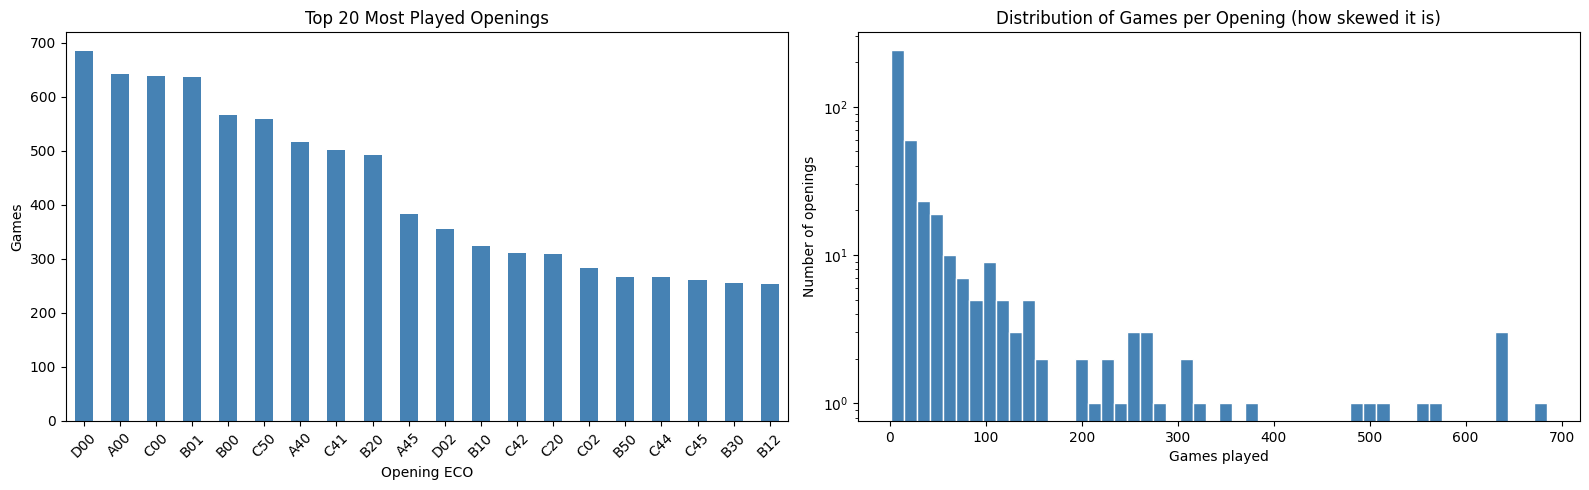

Total unique openings: 417
Median games per opening: 9
Top opening (D00): 685 games


In [144]:
df_raw = pd.read_csv(os.path.join(path, "Chess games stats.csv"))
opening_counts = df_raw['Opening ECO'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 20 most played openings
opening_counts.head(20).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 Most Played Openings')
axes[0].set_xlabel('Opening ECO')
axes[0].set_ylabel('Games')
axes[0].tick_params(axis='x', rotation=45)

# Distribution of games per opening (log scale to handle skew)
axes[1].hist(opening_counts.values, bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Distribution of Games per Opening (how skewed it is)')
axes[1].set_xlabel('Games played')
axes[1].set_ylabel('Number of openings')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

print(f"Total unique openings: {len(opening_counts)}")
print(f"Median games per opening: {opening_counts.median():.0f}")
print(f"Top opening ({opening_counts.index[0]}): {opening_counts.iloc[0]} games")

In [145]:
df_player.describe()

,player_rating,opponent_rating,player_white,opening_ply,elo_delta_ratio,opening_frequency,player_centipawn_loss,opponent_centipawn_loss,time_control_encoded,opening_familiarity,player_rapid_rating,opponent_rapid_rating,player_rapid_games,opponent_rapid_games,player_blitz_rating,opponent_blitz_rating,player_blitz_games,opponent_blitz_games,player_bullet_rating,opponent_bullet_rating,player_bullet_games,opponent_bullet_games,player_total_games,opponent_total_games,player_play_time_secs,opponent_play_time_secs,player_blitz_vs_rapid,player_bullet_vs_blitz,player_bullet_vs_rapid,opponent_blitz_vs_rapid,opponent_bullet_vs_blitz,opponent_bullet_vs_rapid,rapid_rating_gap,blitz_rating_gap,total_games_gap,rapid_games_gap,play_time_gap
count,37274.000000,37274.000000,37274.000000,37274.000000,3.727400e+04,37274.000000,37274.000000,37274.000000,37274.0,37274.000000,31624.000000,31624.000000,37274.000000,37274.000000,31624.000000,31624.000000,37274.000000,37274.000000,31624.000000,31624.000000,37274.000000,37274.000000,3.727400e+04,3.727400e+04,3.727400e+04,3.727400e+04,31624.000000,31624.000000,31624.000000,31624.000000,31624.000000,31624.000000,26946.000000,26946.000000,3.727400e+04,37274.000000,3.727400e+04
mean,1775.629098,1775.629098,0.500000,5.319043,-9.531345e-20,1.890111,59.796373,59.796373,3.0,1.122606,1782.062453,1782.062453,2792.628052,2792.628052,1610.237004,1610.237004,3044.225868,3044.225868,1506.175089,1506.175089,1882.183130,1882.183130,7.980230e+03,7.980230e+03,4.113660e+06,4.113660e+06,-171.825449,-104.061915,-275.887364,-171.825449,-104.061915,-275.887364,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00
std,316.132670,316.132670,0.500007,3.058213,1.179572e-01,0.361907,37.491296,37.491296,0.0,0.437236,322.225414,322.225414,8600.006713,8600.006713,345.284185,345.284185,8333.168250,8333.168250,359.862164,359.862164,7868.070267,7868.070267,2.056761e+04,2.056761e+04,1.609195e+07,1.609195e+07,208.738120,250.066894,294.751319,208.738120,250.066894,294.751319,277.859184,342.591952,2.899462e+04,12210.382977,2.275571e+07
min,780.000000,780.000000,0.000000,1.000000,-8.586847e-01,0.000000,0.000000,0.000000,3.0,1.000000,500.000000,500.000000,0.000000,0.000000,511.000000,511.000000,0.000000,0.000000,400.000000,400.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1390.000000,-1249.000000,-1699.000000,-1390.000000,-1249.000000,-1699.000000,-1501.000000,-1655.000000,-1.283597e+06,-526939.000000,-1.235643e+09
25%,1551.000000,1551.000000,0.000000,3.000000,-4.517563e-02,2.000000,33.000000,33.000000,3.0,1.000000,1561.000000,1561.000000,46.000000,46.000000,1380.000000,1380.000000,2.000000,2.000000,1282.000000,1282.000000,0.000000,0.000000,1.640000e+02,1.640000e+02,1.595872e+05,1.595872e+05,-287.000000,-253.000000,-470.000000,-287.000000,-253.000000,-470.000000,-167.000000,-214.000000,-4.949500e+03,-1406.750000,-2.716504e+06
50%,1782.000000,1782.000000,0.500000,5.000000,0.000000e+00,2.000000,54.000000,54.000000,3.0,1.000000,1792.000000,1792.000000,573.000000,573.000000,1573.000000,1573.000000,229.000000,229.000000,1500.000000,1500.000000,5.000000,5.000000,2.222500e+03,2.222500e+03,1.472099e+06,1.472099e+06,-164.000000,-89.000000,-278.000000,-164.000000,-89.000000,-278.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00
75%,1994.000000,1994.000000,1.000000,7.000000,4.517563e-02,2.000000,79.000000,79.000000,3.0,1.000000,2007.000000,2007.000000,2527.000000,2527.000000,1833.000000,1833.000000,2700.750000,2700.750000,1638.000000,1638.000000,355.000000,355.000000,9.617000e+03,9.617000e+03,5.075163e+06,5.075163e+06,-52.000000,43.000000,-82.000000,-52.000000,43.000000,-82.000000,167.000000,214.000000,4.949500e+03,1406.750000,2.716504e+06
max,2997.000000,2997.000000,1.000000,28.000000,8.586847e-01,2.000000,550.000000,550.000000,3.0,6.000000,3122.000000,3122.000000,527294.000000,527294.000000,3014.000000,3014.000000,403686.000000,403686.000000,3300.000000,3300.000000,212726.000000,212726.000000,1.284783e+06,1.284

In [146]:
df_player.columns

Index(['Game ID', 'player_rating', 'opponent_rating', 'player_white',
       'opening_ply', 'elo_delta_ratio', 'opening_frequency',
       'player_centipawn_loss', 'opponent_centipawn_loss', 'time_control',
       'time_control_encoded', 'player_username', 'opponent_username',
       'opening_familiarity', 'player_rapid_rating', 'opponent_rapid_rating',
       'player_rapid_games', 'opponent_rapid_games', 'player_blitz_rating',
       'opponent_blitz_rating', 'player_blitz_games', 'opponent_blitz_games',
       'player_bullet_rating', 'opponent_bullet_rating', 'player_bullet_games',
       'opponent_bullet_games', 'player_total_games', 'opponent_total_games',
       'player_play_time_secs', 'opponent_play_time_secs',
       'player_avg_game_secs', 'opponent_avg_game_secs',
       'player_blitz_vs_rapid', 'player_bullet_vs_blitz',
       'player_bullet_vs_rapid', 'opponent_blitz_vs_rapid',
       'opponent_bullet_vs_blitz', 'opponent_bullet_vs_rapid',
       'player_rapid_ratio', 'playe

In [148]:
nan_summary = pd.DataFrame({
    'null_count': df_player.isnull().sum(),
})
nan_summary[nan_summary['null_count'] == 0].sort_values('null_count', ascending=False)

,null_count
Game ID,0
player_rating,0
opponent_rating,0
player_white,0
opening_ply,0
elo_delta_ratio,0
opening_frequency,0
player_centipawn_loss,0
opponent_centipawn_loss,0
time_control,0


In [149]:
df_player.to_csv('processed_player_data_v2.csv', index=False)